# 13. Penalty 균형 실험 결과 시각화

notebook 12의 결과로 Figure 12~15를 만듭니다.

| Figure | 내용 | 확인할 것 |
|---|---|---|
| 12 | 비율 대 feasible 비율 | 개선이 있는가, 최적 비율은 어디인가 |
| 13 | 비율 대 optimality gap | feasibility 개선이 품질로 이어지는가 |
| 14 | 정규화된 제약 강도와 ICE 노이즈 | **불균형을 직접 보여주는 그림** |
| 15 | 비율 대 coefficient range | 어디까지가 공짜인가 |

오프라인과 QPU 결과가 모두 있으면 Figure 12, 13에 함께 표시됩니다. **두 곡선의 차이가 곧 하드웨어가 잃는 양**입니다.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from src.config import load_config, resolve_path

config = load_config(PROJECT_ROOT / "config" / "experiment_config.yaml")
DATA_DIR = resolve_path(config, "data_dir")
RAW_DIR = resolve_path(config, "raw_dir")
PROCESSED_DIR = resolve_path(config, "processed_dir")
FIGURE_DIR = resolve_path(config, "figure_dir")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("설정 로드 완료")


설정 로드 완료


In [2]:
from src.persistence import load_table
from src import balance_plotting as BP
from src import penalty_balance as PB

results = load_table(PROCESSED_DIR, "penalty_balance.csv")
print(results.groupby(["mode", "instance", "formulation"]).size())
results

mode     instance  formulation
offline  15x15     SS             9
         4x4       SS             9
         6x6       SS             9
         8x8       SS             9
qpu      15x15     SS             9
         4x4       SS             9
         6x6       SS             9
         8x8       SS             9
dtype: int64


,instance,formulation,mode,capacity_multiplier,ratio,lambda_capacity,lambda_assignment,qubo_variables,qubo_quadratic_terms,qubo_range,max_abs_coupling,assignment_strength,capacity_strength,objective_strength,status,feasible_fraction,best_feasible_objective,true_gap_percent,runtime,sampler,embedding_status,physical_qubits,max_chain_length,mean_chain_length,embedding_search_time,qa_chain_strength,qa_chain_break_fraction,logical_variables
0,4x4,SS,offline,1.1,1.0,5917.16730,5.917167e+03,44,246,5.964599e+07,7.662732e+06,0.001544,2.114286,8.614787e-06,OK,0.009,2593.0879,7.292653,0.422727,SimulatedAnnealing,OK,105,4,2.386364,0.374890,NaN,NaN,NaN
1,4x4,SS,offline,1.1,10.0,5917.16730,5.917167e+04,44,246,5.964599e+07,7.662732e+06,0.015444,2.114286,8.614787e-06,OK,0.020,2416.8364,0.000000,0.444690,SimulatedAnnealing,OK,105,4,2.386364,0.374890,NaN,NaN,NaN
2,4x4,SS,offline,1.1,50.0,5917.16730,2.958584e+05,44,246,5.964599e+07,7.662732e+06,0.077220,2.114286,8.614787e-06,OK,0.047,2426.5714,0.402799,0.444765,SimulatedAnnealing,OK,105,4,2.386364,0.374890,NaN,NaN,NaN
3,4x4,SS,offline,1.1,100.0,5917.16730,5.917167e+05,44,246,5.964599e+07,7.662732e+06,0.154440,2.114286,8.614787e-06,OK,0.129,2416.8364,0.000000,0.445755,SimulatedAnnealing,OK,105,4,2.386364,0.374890,NaN,NaN,NaN
4,4x4,SS,offline,1.1,200.0,5917.16730,1.183433e+06,44,246,5.964599e+07,7.662732e+06,0.308880,2.114286,8.614787e-06,OK,0.217,2416.8364,0.000000,0.443022,SimulatedAnnealing,OK,105,4,2.386364,0.374890,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,15x15,SS,qpu,1.1,200.0,62683.32015,1.253666e+07,329,5026,1.578681e+09,1.874231e+08,0.133779,1.294983,1.327376e-07,OK,0.000,NaN,NaN,1.921158,DWaveSampler,OK,4494,34,13.659574,129.448075,2.811347e+08,0.174374,329.0
68,15x15,SS,qpu,1.1,500.0,62683.32015,3.134166e+07,329,5026,1.578681e+09,1.874231e+08,0.334448,1.294983,1.327376e-07,OK,0.000,NaN,NaN,1.361572,DWaveSampler,OK,4494,34,13.659574,129.448075,2.811347e+08,0.156547,329.0
69,15x15,SS,qpu,1.1,1000.0,62683.32015,6.268332e+07,329,5026,1.578681e+09,1.874231e+08,0.668896,1.294983,1.327376e-07,OK,0.000,NaN,NaN,1.434624,DWaveSampler,OK,4494,34,13.659574,129.448075,2.811347e+08,0.149748,329.0
70,15x15,SS,qpu,1.1,2000.0,62683.32015,1.253666e+08,329,5026,1.578681e+09,1.874231e+08,1.337793,1.294983,1.327376e-07,OK,0.000,NaN,NaN,1.279496,DWaveSampler,OK,4494,34,13.659574,129.448075,2.811347e+08,0.241274,329.0


## Figure 12 — penalty 균형과 feasible 비율

빨간 점선은 coefficient range가 커지기 시작하는 지점입니다. **그 왼쪽에서 얻어진 개선은 range를 전혀 늘리지 않고 얻은 것**입니다.

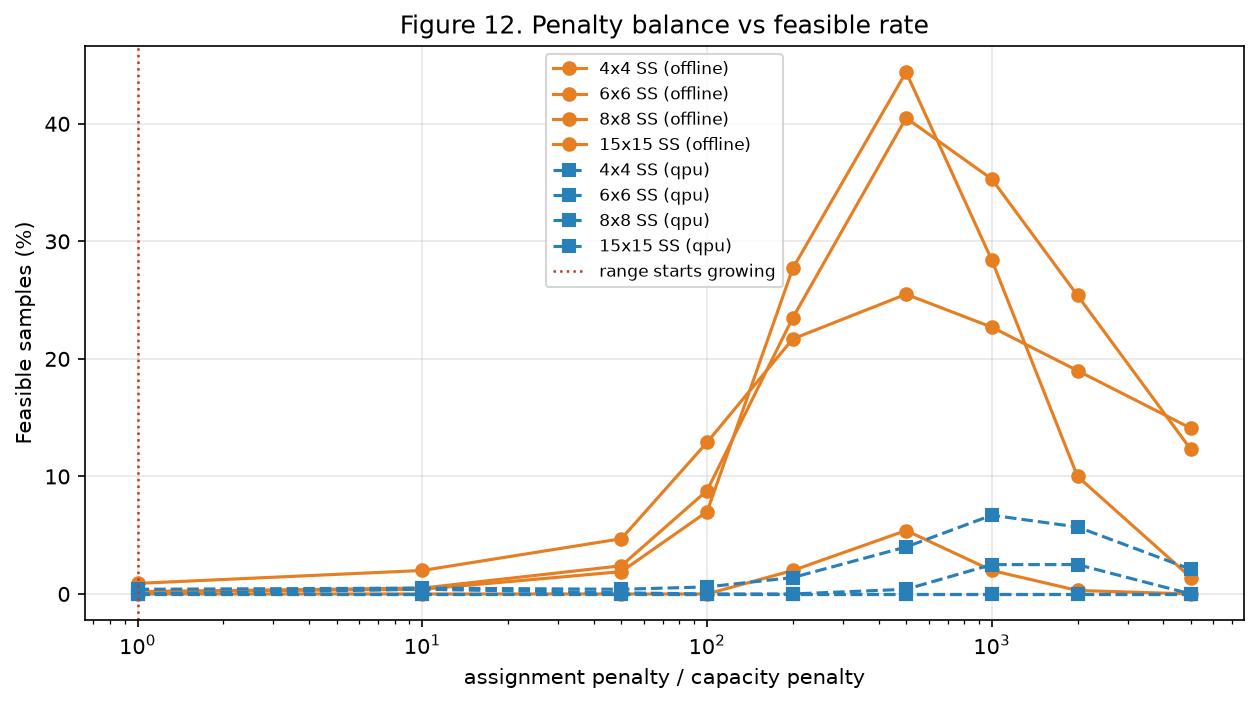

In [3]:
from IPython.display import Image

path = BP.plot_ratio_vs_feasibility(results, FIGURE_DIR)
Image(filename=str(path))

## Figure 13 — penalty 균형과 해의 품질

feasible solution을 더 많이 찾는 것과 더 좋은 solution을 찾는 것은 다릅니다. feasible 비율이 올라가도 gap이 그대로면, 제약은 만족시키되 **그중 어느 것이 싼지는 구분하지 못한다**는 뜻입니다.

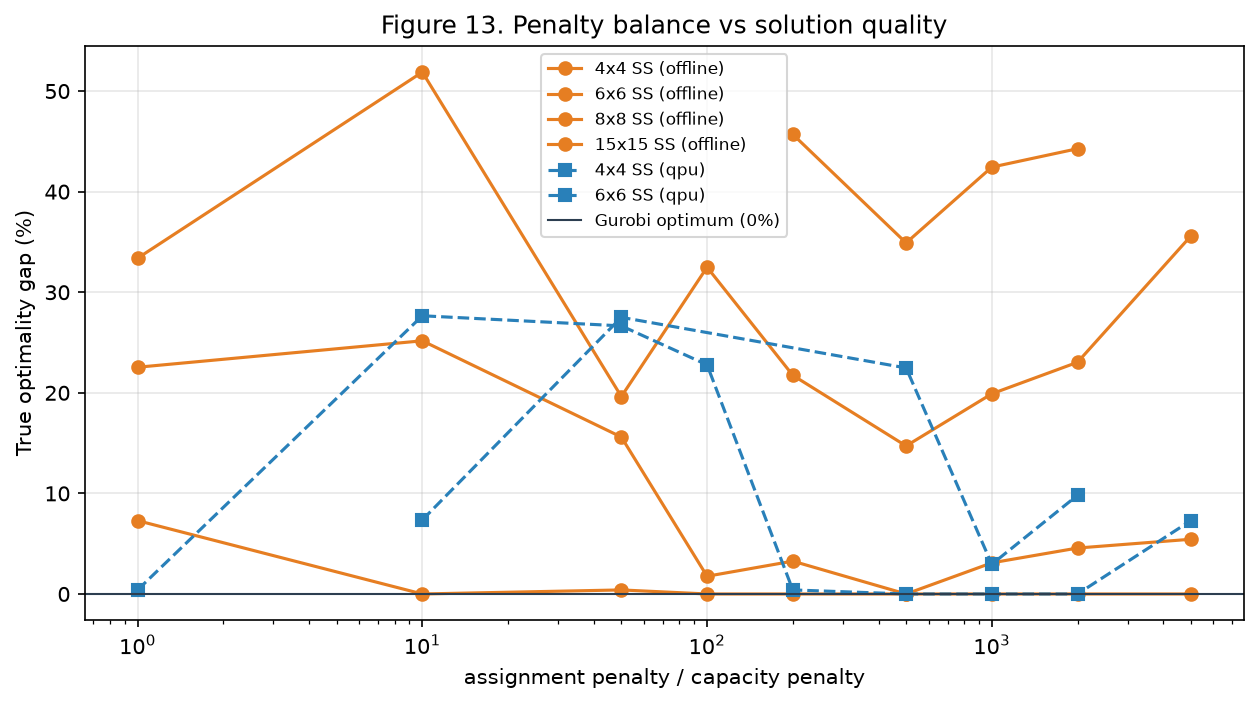

In [4]:
path = BP.plot_ratio_vs_gap(results, FIGURE_DIR)
Image(filename=str(path))

## Figure 14 — 제약 강도와 하드웨어 노이즈

이 실험의 출발점이 된 그림입니다.

`ratio = 1`(기존 설정)에서 assignment 강도가 capacity보다 몇 자릿수 아래인지, 그리고 어느 ratio에서 회색 띠(ICE 노이즈) 위로 올라오는지를 봅니다.

objective 곡선이 계속 띠 아래에 머문다면, **제약은 보이게 만들 수 있어도 objective는 여전히 보이지 않는다**는 뜻입니다.

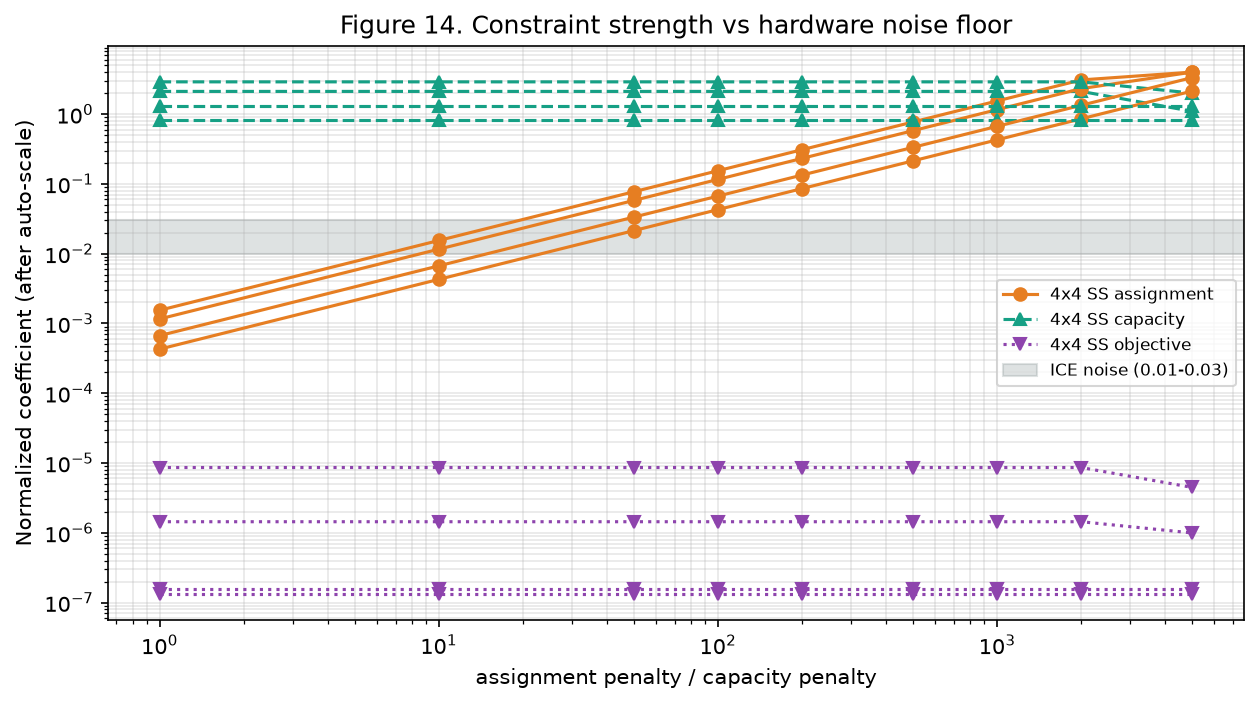

In [5]:
path = BP.plot_constraint_strength(results, FIGURE_DIR)
Image(filename=str(path))

## Figure 15 — penalty 균형과 coefficient range

일정 ratio까지 range가 완전히 평평하다는 것을 보여줍니다. 그 구간의 개선은 **dynamic range를 대가로 치르지 않았습니다.**

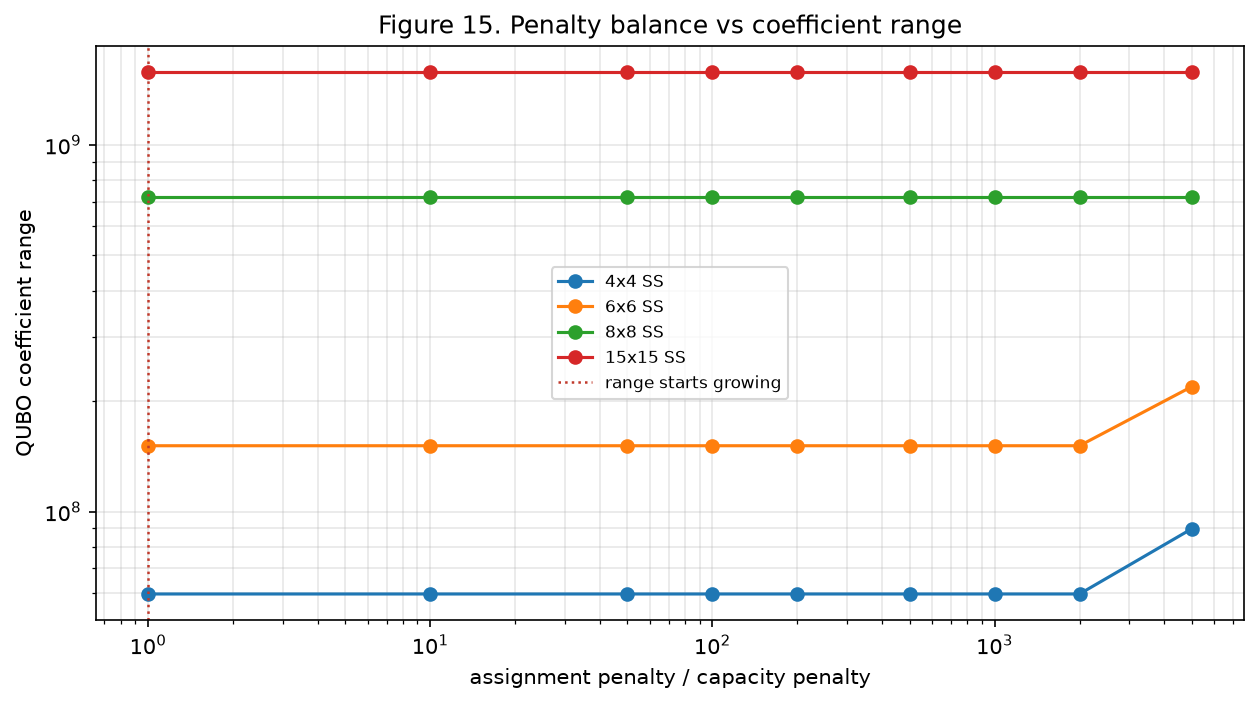

In [6]:
path = BP.plot_ratio_vs_range(results, FIGURE_DIR)
Image(filename=str(path))

## 요약

아래 출력은 관측된 수치만 기술합니다. 오프라인 결과는 노이즈가 없는 이상적 조건이므로, QPU 결과의 **상한**으로 읽어야 합니다.

In [7]:
lines = PB.summarize(results)
for line in lines:
    print(line)

summary_path = PROCESSED_DIR / "penalty_balance_summary.txt"
summary_path.write_text("\n".join(lines), encoding="utf-8")
print("\n저장:", summary_path)

4x4 SS (offline): feasible 0.9% -> 25.5% (ratio=500, 28배), range 5.96e+07 -> 5.96e+07
6x6 SS (offline): feasible 0.2% -> 40.5% (ratio=500, 202배), range 1.51e+08 -> 1.51e+08
8x8 SS (offline): feasible 0.2% -> 44.4% (ratio=500, 222배), range 7.21e+08 -> 7.21e+08
15x15 SS (offline): feasible 0.0% -> 5.4% (ratio=500, 0에서 상승), range 1.58e+09 -> 1.58e+09
4x4 SS (qpu): feasible 0.4% -> 6.7% (ratio=1000, 17배), range 5.96e+07 -> 5.96e+07
6x6 SS (qpu): feasible 0.0% -> 2.5% (ratio=1000, 0에서 상승), range 1.51e+08 -> 1.51e+08
8x8 SS (qpu): feasible 0.0% -> 0.0% (ratio=1, 0에서 상승), range 7.21e+08 -> 7.21e+08
15x15 SS (qpu): feasible 0.0% -> 0.0% (ratio=1, 0에서 상승), range 1.58e+09 -> 1.58e+09

저장: C:\Users\User\Desktop\KMJ\Study\Quantum\cflp_formulation\results\processed\penalty_balance_summary.txt
